# **Install and Import Libraries**

In [ ]:
!pip install flashtext tldextract

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 2.7 MB/s eta 0:00:00
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=a1298c8ebafd0763400a206c244be80c257e167002f533ccb84d0c8eeea71d78
  Stored in directory: /root/.cache/pip/wheels/49/20/47/f03dfa8a7239c54cbc44ff7389eefbf888d2c1873edaaec888
Successfully built flashtext


In [ ]:
import re
import os
import ssl
import math
import socket
import tldextract
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from flashtext import KeywordProcessor
from multiprocessing import Pool, Manager
from urllib.parse import urlparse, urlunparse

# **phishURL1000.csv**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/phishURL1000 (2).csv')
df.head()

,url,label,result
0,https://www.google.com,benign,0
1,https://www.youtube.com,benign,0
2,https://www.facebook.com,benign,0
3,https://www.baidu.com,benign,0
4,https://www.wikipedia.org,benign,0


In [ ]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns')

The dataset has 2225977 rows and 3 columns


result
1    1698267
0     527710
Name: count, dtype: int64


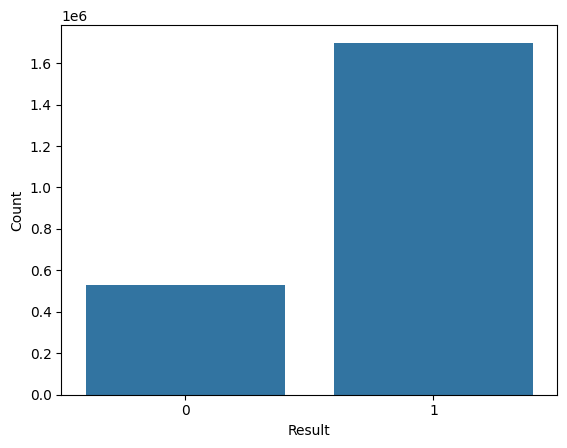

In [ ]:
print(df['result'].value_counts())
sns.countplot(x='result', data=df)
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

## **Data Cleaning**

In [ ]:
df['label'] = df['label'].replace({'benign': 'legitimate', 'malicious': 'phishing'})
df.head()

,url,label,result
0,https://www.google.com,legitimate,0
1,https://www.youtube.com,legitimate,0
2,https://www.facebook.com,legitimate,0
3,https://www.baidu.com,legitimate,0
4,https://www.wikipedia.org,legitimate,0


In [ ]:
df.rename(columns = {'result': 'Target', 'url': 'URL', 'label': 'Label'}, inplace = True)
df.head()

,URL,Label,Target
0,https://www.google.com,legitimate,0
1,https://www.youtube.com,legitimate,0
2,https://www.facebook.com,legitimate,0
3,https://www.baidu.com,legitimate,0
4,https://www.wikipedia.org,legitimate,0


## **Exploratory Data Analysis (EDA)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225977 entries, 0 to 2225976
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   URL     object
 1   Label   object
 2   Target  int64 
dtypes: int64(1), object(2)
memory usage: 50.9+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Target,2225977.0,0.762931,0.425285,0.0,1.0,1.0,1.0,1.0


In [ ]:
# checking missing values
df.isnull().sum()

,0
URL,0
Label,0
Target,0


In [ ]:
# checking duplicate values
print(f'Duplicates: {df.duplicated().sum()}')

Duplicates: 0


In [ ]:
for col in df.columns:
    unique_value_list = df[col].unique()
    if len(unique_value_list) > 10:
        print(f'{col} has {df[col].nunique()} unique values')
    else:
        print(f'{col} contains:\t\t\t{unique_value_list}')

URL has 2225977 unique values
Label contains:			['legitimate' 'phishing']
Target contains:			[0 1]


## **Feature extraction**

### **0. Extract www.**

In [ ]:
def normalize_url(url):
    if '://' not in url:
        url = 'http://' + url  # ensure schema exists

    scheme, rest = url.split("://", 1)
    if rest.startswith('www.'):
        rest = rest[4:]  # remove 'www.'

    return f"{scheme}://{rest}"

# Apply normalization
df['URL'] = df['URL'].apply(normalize_url)
df['URL'] = df['URL'].str.strip().str.rstrip('/')

### **1. URL Length**

In [ ]:
def get_url_len(url):
    return len(url)

In [ ]:
df['URL Length'] = df['URL'].apply(get_url_len)
df.head()

,URL,Label,Target,URL Length
0,https://google.com,legitimate,0,18
1,https://youtube.com,legitimate,0,19
2,https://facebook.com,legitimate,0,20
3,https://baidu.com,legitimate,0,17
4,https://wikipedia.org,legitimate,0,21


### **2. Number of Digits**

In [ ]:
def count_digits(url):
    count = 0
    for i in url:
        if '0' <= i <= '9':
            count += 1
    return count

In [ ]:
df['Digits'] = df['URL'].apply(count_digits)
df.head()

,URL,Label,Target,URL Length,Digits
0,https://google.com,legitimate,0,18,0
1,https://youtube.com,legitimate,0,19,0
2,https://facebook.com,legitimate,0,20,0
3,https://baidu.com,legitimate,0,17,0
4,https://wikipedia.org,legitimate,0,21,0


### **3. URL Depth**

In [ ]:
def count_url_depth(url):
    url1 = url.split("://")[-1]
    return url1.count('/')

In [ ]:
df['URL Depth'] = df['URL'].apply(count_url_depth)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth
0,https://google.com,legitimate,0,18,0,0
1,https://youtube.com,legitimate,0,19,0,0
2,https://facebook.com,legitimate,0,20,0,0
3,https://baidu.com,legitimate,0,17,0,0
4,https://wikipedia.org,legitimate,0,21,0,0


### **4. URL Entropy**

Entropy is randomness factor or uncertainty in URLs

The higher the entropy, the higher the randomness factor in the URL

In [ ]:
def entropy(url):
    frequency = {}
    for char in url:
        if char in frequency:
            frequency[char] += 1
        else:
            frequency[char] = 1

    entropy = 0.0
    length = len(url)
    for count in frequency.values():
        probability = count / length
        if probability > 0:
            entropy -= probability * math.log2(probability)
    return round(entropy, 1)

In [ ]:
df['URL Entropy'] = df['URL'].apply(entropy)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy
0,https://google.com,legitimate,0,18,0,0,3.6
1,https://youtube.com,legitimate,0,19,0,0,3.7
2,https://facebook.com,legitimate,0,20,0,0,3.8
3,https://baidu.com,legitimate,0,17,0,0,3.9
4,https://wikipedia.org,legitimate,0,21,0,0,3.9


### **5. URL Popularity Score**

In [ ]:
def popularity_score(url):
    popular_tlds = ['.com', '.org', '.net', '.gov', '.edu', '.co', '.io', '.ca', '.uk', '.de', '.us']

    tld_score = 5 if any(url.endswith(tld) for tld in popular_tlds) else 2

    if len(url) < 20:
        length_score = 5
    elif len(url) < 30:
        length_score = 3
    else:
        length_score = 1


    subdomain_count = url.count('.') - 1
    subdomain_score = max(1, 5 - subdomain_count)

    score = tld_score + length_score + subdomain_score
    return score

In [ ]:
df['URL Popularity Score'] = df['URL'].apply(popularity_score)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score
0,https://google.com,legitimate,0,18,0,0,3.6,15
1,https://youtube.com,legitimate,0,19,0,0,3.7,15
2,https://facebook.com,legitimate,0,20,0,0,3.8,13
3,https://baidu.com,legitimate,0,17,0,0,3.9,15
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13


### **6. URL Domain**

In [ ]:
def get_domain(url):
    if '://' in url:
        url = url.split('://')[1]
    if 'www.' in url:
        url = url.split('www.')[1]
    domain = url.split('/')[0]
    return domain

In [ ]:
df['URL Domain'] = df['URL'].apply(get_domain)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org


### **7. Number of Sub-Domains**

In [ ]:
def count_subdomain(url):
    if '://' in url:
        url = url.split('://')[1]
    domain_part = url.split('/')[0]
    parts = domain_part.split('.')
    if len(parts) < 2:
        return 0
    return len(parts) - 2

In [ ]:
df['Sub-Domain'] = df['URL'].apply(count_subdomain)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0


### **8. Domain Entropy**

In [ ]:
def calculate_entropy(url):
    domain = get_domain(url)
    frequency = {}
    for char in domain:
        if char in frequency:
            frequency[char] += 1
        else:
            frequency[char] = 1

    total_chars = len(domain)

    entropy = 0.0
    for count in frequency.values():
        probability = count / total_chars
        # The log2 function is correctly used here within the function
        entropy -= probability * (0 if probability == 0 else math.log2(probability))

    return round(entropy, 1)

In [ ]:
df['Domain Entropy'] = df['URL'].apply(calculate_entropy)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3


### **9. Path Length**

In [ ]:
def path_length(url):
    path_start = url.find('/', url.find('//') + 2)

    if path_start == -1:
        return 0

    path_end = url.find('?') if '?' in url else len(url)
    path = url[path_start:path_end]

    return len(path)

In [ ]:
df['Path Length'] = df['URL'].apply(path_length)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0


### **10. Special Characters**

In [ ]:
def count_special_char(url):
    special_char = ['-', '_', '.', '=', '?', '&', '@', '#', '%', ':', '~']
    return sum(url.count(char) for char in special_char)

In [ ]:
df['Special Characters'] = df['URL'].apply(count_special_char)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length,Special Characters
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0,2
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0,2
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0,2
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0,2
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0,2


### **11. HTTPS**

In [ ]:
def has_https(url):
    if url.startswith('https://'):
        return 1
    else:
        return 0

In [ ]:
df['Has HTTPS'] = df['URL'].apply(has_https)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length,Special Characters,Has HTTPS
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0,2,1
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0,2,1
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0,2,1
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0,2,1
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0,2,1


### **12. IP Address**

In [ ]:
def has_ip(url):
    main_part = url.split('/')[2] if '//' in url else url.split('/')[0]
    parts = main_part.split('.')

    if len(parts) == 4:
        for part in parts:
            if not part.isdigit() or not (0 <= int(part) <= 255):
                return 0
        return 1
    return 0

In [ ]:
df['Has IP'] = df['URL'].apply(has_ip)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length,Special Characters,Has HTTPS,Has IP
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0,2,1,0
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0,2,1,0
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0,2,1,0
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0,2,1,0
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0,2,1,0


### **13. Registered Company Domain**

https://www.kaggle.com/datasets/mfrye0/bigpicture-company-dataset

In [ ]:
usecols = ['website']  # Only load the column you need
df_companies1 = pd.read_csv('/content/drive/MyDrive/Dataset/companies-2023-q4-sm.csv', usecols=usecols)

In [ ]:
domains_1 = df_companies1['website'].dropna().str.lower().str.strip() \
    .str.replace('http://', '', regex=False) \
    .str.replace('https://', '', regex=False) \
    .str.replace('www.', '', regex=False) \
    .str.extract(r'^([a-z0-9.-]+)')[0]

In [ ]:
registered_domains = set(domains_1.dropna())

In [ ]:
def is_registered_company_domain(url):
    try:
        ext = tldextract.extract(url)
        domain = f"{ext.domain}.{ext.suffix}".lower()
        return 1 if domain in registered_domains else 0
    except:
        return 0

In [ ]:
df['Is Registered Company Domain'] = df['URL'].apply(is_registered_company_domain)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length,Special Characters,Has HTTPS,Has IP,Is Registered Company Domain
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0,2,1,0,1
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0,2,1,0,1
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0,2,1,0,1
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0,2,1,0,1
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0,2,1,0,1


📊 Domain Registration Status by URL Label:

Is Registered Company Domain        0       1
Target                                       
Legitimate                     219205  308505
Phishing                      1269408  428859


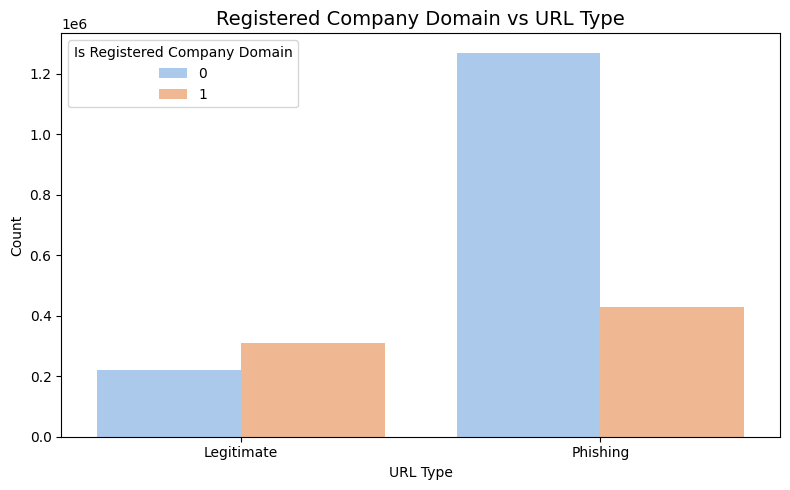

In [ ]:
# Summary count
counts = df.groupby(['Target', 'Is Registered Company Domain']).size().unstack().fillna(0)

# Rename for clarity
counts.index = counts.index.map({0: 'Legitimate', 1: 'Phishing'})

print("📊 Domain Registration Status by URL Label:\n")
print(counts)

# Visualize
plt.figure(figsize=(8, 5))
sns.barplot(data=counts.reset_index().melt(id_vars='Target'),
            x='Target', y='value', hue='Is Registered Company Domain', palette='pastel')
plt.title("Registered Company Domain vs URL Type", fontsize=14)
plt.xlabel("URL Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### **14. Suspicious Keywords**

In [ ]:
def has_suspicious_keywords(url, is_registered):
    suspicious_keywords = [
        'login', 'signin', 'account', 'verify', 'update', 'secure', 'bank',
        'password', 'confirm', 'billing', 'payment', 'invoice', 'card',
        'pin', 'ssn', 'security', 'credential', 'checkout', 'wallet'
    ]
    url_lower = url.lower()
    count = sum(1 for keyword in suspicious_keywords if keyword in url_lower)

    if count >= 2:
        return 1
    elif count == 1 and not is_registered:
        return 1
    return 0

In [ ]:
df['Has Suspicious Keywords'] = df.apply(
    lambda row: has_suspicious_keywords(row['URL'], row['Is Registered Company Domain']), axis=1)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length,Special Characters,Has HTTPS,Has IP,Is Registered Company Domain,Has Suspicious Keywords
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0,2,1,0,1,0
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0,2,1,0,1,0
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0,2,1,0,1,0
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0,2,1,0,1,0
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0,2,1,0,1,0


### **15. TLD Value**

In [ ]:
def get_tld(url):
    if '://' in url:
        url = url.split('://')[1]
    url = url.replace("www.", "")
    domain_part = url.split('/')[0].split(':')[0]
    parts = domain_part.split('.')
    return parts[-1] if len(parts) > 1 else None

In [ ]:
df['TLD'] = df['URL'].apply(get_tld)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length,Special Characters,Has HTTPS,Has IP,Is Registered Company Domain,Has Suspicious Keywords,TLD
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0,2,1,0,1,0,com
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0,2,1,0,1,0,com
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0,2,1,0,1,0,com
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0,2,1,0,1,0,com
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0,2,1,0,1,0,org


### **16. Suspicious TLD**

https://github.com/mthcht/awesome-lists/blob/main/Lists/suspicious_tlds_list.csv

In [ ]:
suspicious_tlds_df = pd.read_csv("/content/drive/MyDrive/Dataset/suspicious_tlds_list.csv")
suspicious_tlds = set(suspicious_tlds_df['metadata_tld'].dropna().str.lower())

In [ ]:
def has_suspicious_tld(url):
    tld = get_tld(url)
    if tld is None:
        return 0
    return 1 if tld.lower() in suspicious_tlds else 0

In [ ]:
df['Has Suspicious TLD'] = df['URL'].apply(has_suspicious_tld)
df.head()

,URL,Label,Target,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Path Length,Special Characters,Has HTTPS,Has IP,Is Registered Company Domain,Has Suspicious Keywords,TLD,Has Suspicious TLD
0,https://google.com,legitimate,0,18,0,0,3.6,15,google.com,0,2.6,0,2,1,0,1,0,com,0
1,https://youtube.com,legitimate,0,19,0,0,3.7,15,youtube.com,0,3.1,0,2,1,0,1,0,com,0
2,https://facebook.com,legitimate,0,20,0,0,3.8,13,facebook.com,0,3.0,0,2,1,0,1,0,com,0
3,https://baidu.com,legitimate,0,17,0,0,3.9,15,baidu.com,0,3.2,0,2,1,0,1,0,com,0
4,https://wikipedia.org,legitimate,0,21,0,0,3.9,13,wikipedia.org,0,3.3,0,2,1,0,1,0,org,0


## **Arrange Columns**

In [ ]:
#df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
df.columns

Index(['URL', 'Label', 'Target', 'URL Length', 'Digits', 'URL Depth',
       'URL Entropy', 'URL Popularity Score', 'URL Domain', 'Sub-Domain',
       'Domain Entropy', 'Path Length', 'Special Characters', 'Has HTTPS',
       'Has IP', 'Is Registered Company Domain', 'Has Suspicious Keywords',
       'TLD', 'Has Suspicious TLD', 'Is URL Shortened'],
      dtype='object')

In [ ]:
df = df[['URL', 'URL Length', 'Digits', 'URL Depth', 'URL Entropy',
       'URL Popularity Score', 'URL Domain', 'Sub-Domain', 'Domain Entropy', 'Is Registered Company Domain',
       'Path Length', 'Special Characters', 'Has HTTPS', 'Has IP',
       'Has Suspicious Keywords', 'TLD', 'Has Suspicious TLD', 'Label','Target']]

In [ ]:
df

,URL,URL Length,Digits,URL Depth,URL Entropy,URL Popularity Score,URL Domain,Sub-Domain,Domain Entropy,Is Registered Company Domain,Path Length,Special Characters,Has HTTPS,Has IP,Has Suspicious Keywords,TLD,Has Suspicious TLD,Label,Target
0,https://google.com,18,0,0,3.6,15,google.com,0,2.6,1,0,2,1,0,0,com,0,legitimate,0
1,https://youtube.com,19,0,0,3.7,15,youtube.com,0,3.1,1,0,2,1,0,0,com,0,legitimate,0
2,https://facebook.com,20,0,0,3.8,13,facebook.com,0,3.0,1,0,2,1,0,0,com,0,legitimate,0
3,https://baidu.com,17,0,0,3.9,15,baidu.com,0,3.2,1,0,2,1,0,0,com,0,legitimate,0
4,https://wikipedia.org,21,0,0,3.9,13,wikipedia.org,0,3.3,1,0,2,1,0,0,org,0,legitimate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2225972,https://secure.kwsp.gov.my/member/login,39,0,2,4.3,6,secure.kwsp.gov.my,2,3.7,1,13,4,1,0,1,my,0,legitimate,0
2225973,https://login.yahoo.com,23,0,0,3.8,12,login.yahoo.com,1,3.2,1,0,3,1,0,0,com,0,legitimate,0
2225974,https://accounts.zoho.com/login,31,0,1,3.9,7,accounts.zoho.com,1,3.2,1,6,3,1,0,1,com,0,legitimate,0
2225975,https://mail.protonmail.com/login,33,0,1,3.8,7,mail.protonmail.com,1,3.3,1,6,3,1,0,0,com,0,legitimate,0


In [ ]:
df.to_csv('CombinedData.csv')